In [35]:
import numpy as np
import gymnasium as gym
import importlib
import envs

from qrtd import Params

params = Params(
    model_name="Walkway",
    n_runs=1,
    n_episodes=1_000,
    save_skip=10,
    lr_decay=200,
    seed=123,
    
    N=32,
    alpha=1.0,
    gamma=0.99,
    epsilon=0.1,
    
    nA=None,
    nS=None,
    shape=None,
)
tau = (np.arange(params.N) + 0.5) / params.N
env = gym.make(params.model_name)
params = params._replace(nA=int(env.action_space.n))
params = params._replace(nS=int(env.observation_space.n))
params = params._replace(shape=env.unwrapped.shape)
s_init, _ = env.reset()

save_to = None#"experiments/"+params.model_name

In [ ]:
import analysis
import qrtd
importlib.reload(analysis)
importlib.reload(qrtd)

from learners import PolicyIteration, MonteCarlo
from analysis import *
from qrtd import train_qrtd

policy, V_pi = PolicyIteration(env, params.gamma)
table_qrtd0 = train_qrtd(env, policy, params, kappa=0, rho_type="manual")
table_qrtd1 = train_qrtd(env, policy, params, kappa=1, rho_type="manual")

params_td = params._replace(N=1)
table_td = train_qrtd(env, policy, params_td, rho_type="manual")

returns = MonteCarlo(env, policy, params.gamma, total_episodes=5_000)
tau_returns = np.quantile(np.sort(returns), tau)

100%|██████████| 5000/5000 [00:00<00:00, 17019.30it/s]


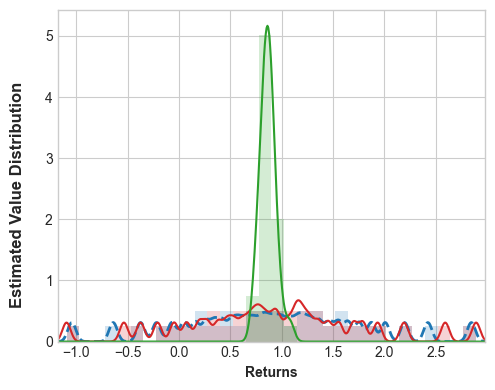

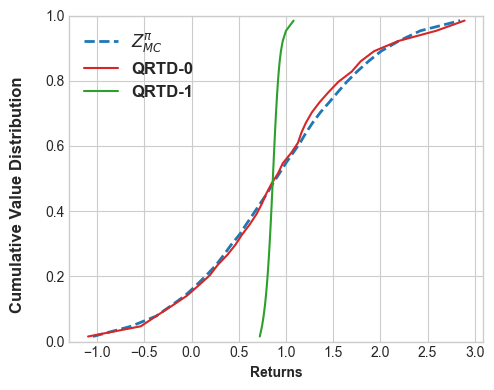

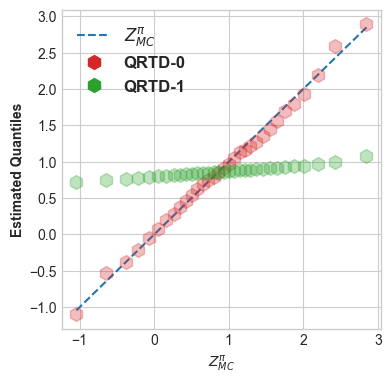

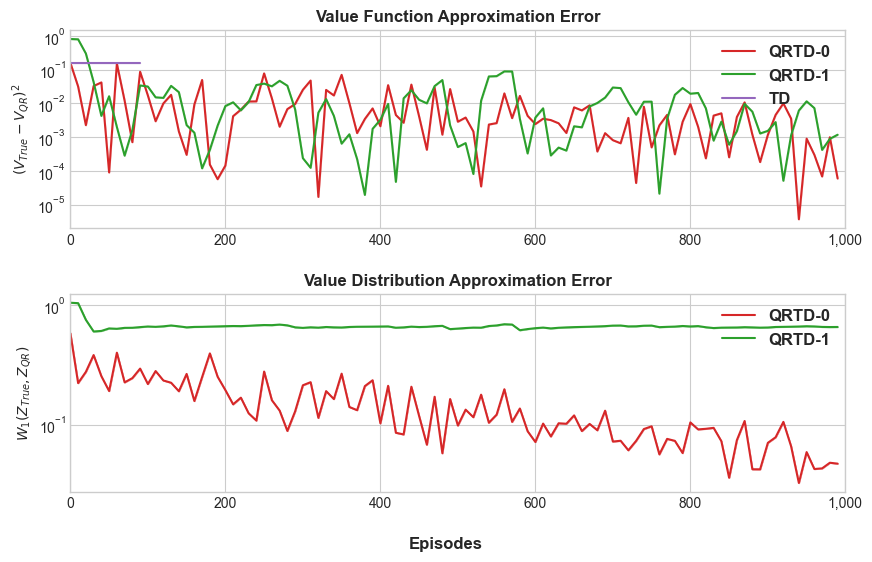

In [38]:
init_qrtd0 = table_qrtd0.mean(0)[-1,0]
init_qrtd1 = table_qrtd1.mean(0)[-1,0]

plot_objs = [(init_qrtd0, "QRTD-0"), (init_qrtd1, "QRTD-1")]
plot_qs = [(table_qrtd0[:,:,s_init], "QRTD-0"), (table_qrtd1[:,:,s_init], "QRTD-1"), (table_td[:,:,s_init], "TD")]

LOW_BANDWIDTH = 0.004
plot_pdf(plot_objs, tau_returns, bandwidth=0.04, show_hist=True, N=params.N, save_to=save_to)
plot_cdf(plot_objs, tau_returns, tau, save_to=save_to)
plot_qq(plot_objs, tau_returns, save_to=save_to)
plot_metrics(plot_qs, tau_returns, save_skip=params.save_skip, save_to=save_to, alphas=[0.15,0.3])

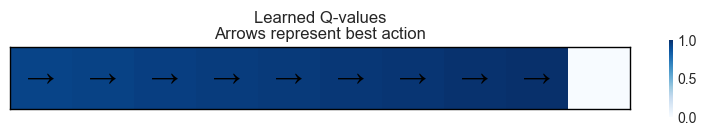

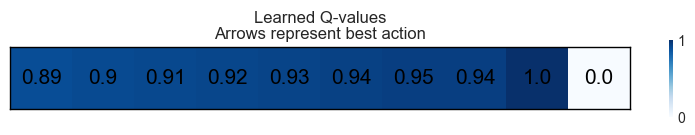

In [37]:
plot_map(policy, params, is_policy=True, V=V_pi)
# plot_map(table_qrtd0[0,-1,:,:params.N//2].mean(-1), params)
plot_map(table_qrtd0[0,-1].mean(-1), params)